# Problem

**State Space**

The state space consists of two discrete states:
$$
\mathcal{X} = \{0, 1\}.
$$

These can be interpreted as two different situations or system configurations, for instance, a “low-performance” state (0) and a “high-performance” state (1).

 **Action Space**

The action space consists of two discrete actions:
$$
\mathcal{A} = \{0, 1\}.
$$

These actions can be thought of as two control options available to the agent — for example:

* **Action 0**: Conservative or “stay” action (keeps the system near state 0)
* **Action 1**: Aggressive or “move” action (pushes the system toward state 1)

**Reward Function**

The reward is explicitly given by:
$$
r(x,a) = x + a.
$$

This means:
* Rewards increase with higher actions.
* Being in the “high” state (1) also provides additional reward.

**Transition Function**

Deterministic transition dynamics:

* If the agent takes **action 0**, it always transitions to state 0.
* If the agent takes **action 1**, it always transitions to state 1.

In tabular form:

| Current (x,a) | P(x′=0) | P(x′=1) |
| ------------- | ------- | ------- |
| (0,0)         | 1.0     | 0.0     |
| (0,1)         | 0.0     | 1.0     |
| (1,0)         | 1.0     | 0.0     |
| (1,1)         | 0.0     | 1.0     |

In [2]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def tensor64(data):
    return torch.as_tensor(data, dtype=torch.float64)

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"
# Add project root to the Python path
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods import FOGASSolverBeta, FOGASHyperOptimizer, FOGASEvaluator, PolicySolver, FOGASSolverBetaVectorized, FOGASSolverPolicy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Tabular Features

## Definition

**Feature Map** 

We use a one-hot feature representation over state–action pairs.  
Each feature corresponds to a unique \((x,a)\) combination.

The feature map is defined as:
$$
\phi(x,a) \in \mathbb{R}^4
$$

with the ordering:
$$
(0,0) \rightarrow e_0,\quad
(0,1) \rightarrow e_1,\quad
(1,0) \rightarrow e_2,\quad
(1,1) \rightarrow e_3
$$

**Reward Weights**

The reward function is linear in the features:
$$
r(x,a) = \phi(x,a)^\top \omega,
$$

with weight vector:
$$
\omega =
\begin{bmatrix}
0 \\
1 \\
1 \\
2
\end{bmatrix}.
$$

**Transition Weights**

The transition model is also linear in the features:
$$
p(x' \mid x,a) = \phi(x,a)^\top \psi(x').
$$

The transition weight vectors are:
$$
\psi(0) =
\begin{bmatrix}
1 \\
0 \\
1 \\
0
\end{bmatrix},
\quad
\psi(1) =
\begin{bmatrix}
0 \\
1 \\
0 \\
1
\end{bmatrix}.
$$


## Testing

In [3]:
states_2d = torch.arange(2, dtype=torch.long)
actions_2d = torch.arange(2, dtype=torch.long)
gamma_2d = 0.99
x_0 = 0 # fixed initial state

def phi(state, action):
    vec = torch.zeros(4, dtype=torch.float64)
    vec[int(state) * 2 + int(action)] = 1.0
    return vec

omega = tensor64([0, 1.0, 1.0, 2.0])

psi = {
    0: tensor64([1.0, 0, 1.0, 0]),
    1: tensor64([0, 1.0, 0, 1.0])
}


mdp = PolicySolver(states=states_2d, actions=actions_2d, phi=phi, omega=omega, gamma=gamma_2d, x0=x_0, psi=psi)

# Empirical

### Beta

In [14]:
solver_e = FOGASSolverBeta(mdp=mdp, print_params=True, csv_path=str(DATASETS_DIR / "dumb_problem.csv"), seed=SEED, device=DEVICE)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"))


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/dumb_problem.csv (n=100)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           100
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      46.27564263195184
T (iterations):                47

FOGAS Hyperparameters
---------------------
alpha:                        0.000859
rho:                            1945.036816
eta:                            0.000070
D_theta:                    20.000000
beta (ridge):             0.005319
D_pi (derived):           0.807192




Trying same optimal hyperparameters found for the oracle.

In [10]:
solver_e.run(alpha=1e-2, eta=1e-3, rho=0.5, tqdm_print=True, T=800)
evaluator_e.compare_value_functions()
evaluator_e.compare_final_rewards()

FOGAS:   0%|          | 0/800 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 800/800 [00:41<00:00, 19.11it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^π(x) =  153.514115 | Δ = -4.548589e+01
State 1: V*(x) =  200.000000 | V^π(x) =  154.268071 | Δ = -4.573193e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^π(x,a) =  151.978974 | Δ = -4.503103e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^π(x,a) =  153.725390 | Δ = -4.527461e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^π(x,a) =  152.978974 | Δ = -4.503103e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^π(x,a) =  154.725390 | Δ = -4.527461e+01

Norm diagnostics:
||V^π - V*||_2 = 6.450097e+01
||Q^π - Q*||_2 = 9.030596e+01



========== FINAL REWARD COMPARISON ==========

J*(π*)   = 1.990000
J(π_FOGAS) = 1.535141
Gap (J* − J) = 4.548589e-01




In [11]:
evaluator_e.print_policy()

  State 0: π(a=0|s=0) = 0.12  π(a=1|s=0) = 0.88  --> best action: 1
  State 1: π(a=0|s=1) = 0.26  π(a=1|s=1) = 0.74  --> best action: 1



### Policy

In [4]:
solver_e = FOGASSolverPolicy(
    mdp=mdp,
    print_params=True,
    csv_path=str(DATASETS_DIR / "dumb_problem.csv"),
    seed=SEED,
    device=DEVICE,
)

evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    metric_callable=evaluator_e.get_metric("reward"),
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/dumb_problem.csv (n=100)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           100
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      46.27564263195184
T (iterations):                47

FOGAS Hyperparameters
---------------------
alpha:                        0.000859
rho:                            1945.036816
eta:                            0.000070
D_theta:                    20.000000
beta (ridge):             0.005319
D_pi (derived):           0.807192




In [7]:
pi = solver_e.run(
    policy_variant="gradient",
    eta_pi=1e-4,
    K_pi=1,
    verbose=True,
    T = 200
)


[FOGAS] Iter 1/200
  θ_t     = tensor([-14.1421, -14.1421,  -0.0000,  -0.0000])
  ||θ_t|| = 2.000e+01
  β_t     = tensor([ 2.6744e-05,  9.3503e-04, -7.8479e-04,  1.2350e-04])
  ||β_t|| = 1.227e-03
  J_before = 2.653e-03
  J_after  = 2.653e-03
  ||∇J||   = 0.000e+00
  cos(θ,∇J) = 0.000e+00

[FOGAS] Iter 21/200
  θ_t     = tensor([-15.0828, -11.9764,  -5.1005,  -1.7491])
  ||θ_t|| = 2.000e+01
  β_t     = tensor([ 0.0009,  0.0049, -0.0036,  0.0003])
  ||β_t|| = 6.110e-03
  J_before = 5.017e-03
  J_after  = 5.017e-03
  ||∇J||   = 1.349e-06
  cos(θ,∇J) = 5.352e-02

[FOGAS] Iter 41/200
  θ_t     = tensor([-15.0650, -11.9758,  -5.1346,  -1.8055])
  ||θ_t|| = 2.000e+01
  β_t     = tensor([ 0.0010,  0.0049, -0.0036,  0.0002])
  ||β_t|| = 6.189e-03
  J_before = 4.546e-03
  J_after  = 4.546e-03
  ||∇J||   = 1.340e-06
  cos(θ,∇J) = 5.626e-02

[FOGAS] Iter 61/200
  θ_t     = tensor([-15.0638, -11.9767,  -5.1351,  -1.8081])
  ||θ_t|| = 2.000e+01
  β_t     = tensor([ 0.0010,  0.0049, -0.0036,  0.000

### Empirical vectorized

In [ ]:
solver_e = FOGASSolverBetaVectorized(mdp=mdp, print_params=True, csv_path=str(DATASETS_DIR / "dumb_problem.csv"), seed=SEED, device=DEVICE)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"))


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/dumb_problem.csv (n=100)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           100
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      46.27564263195184
T (iterations):                47

FOGAS Hyperparameters
---------------------
alpha:                        0.000859
rho:                            1945.036816
eta:                            0.000070
D_theta:                    20.000000
beta (ridge):             0.005319
D_pi (derived):           0.807192




Trying same optimal hyperparameters found for the oracle.

In [22]:
solver_e.run(alpha=1e-2, eta=4e-3, rho=0.5, tqdm_print=True, T=1000)
evaluator_e.compare_value_functions()
evaluator_e.compare_final_rewards()

FOGAS:   0%|          | 0/1000 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 1000/1000 [00:00<00:00, 2092.10it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^π(x) =  151.853818 | Δ = -4.714618e+01
State 1: V*(x) =  200.000000 | V^π(x) =  152.449827 | Δ = -4.755017e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^π(x,a) =  150.335280 | Δ = -4.667472e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^π(x,a) =  151.925329 | Δ = -4.707467e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^π(x,a) =  151.335280 | Δ = -4.667472e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^π(x,a) =  152.925329 | Δ = -4.707467e+01

Norm diagnostics:
||V^π - V*||_2 = 6.696104e+01
||Q^π - Q*||_2 = 9.375024e+01



========== FINAL REWARD COMPARISON ==========

J*(π*)   = 1.990000
J(π_FOGAS) = 1.518538
Gap (J* − J) = 4.714618e-01




In [23]:
evaluator_e.print_policy()

  State 0: π(a=0|s=0) = 0.04  π(a=1|s=0) = 0.96  --> best action: 1
  State 1: π(a=0|s=1) = 0.30  π(a=1|s=1) = 0.70  --> best action: 1



# Funky Features

## Definition

**Feature Map**

The MDP follows the **Linear MDP assumption**, where both the reward and transition dynamics are linear in a known feature map $ \phi(x,a) $.

The feature representation is defined as:
$$
\phi(x,a) = 2 *
\begin{bmatrix}
1 \\
x \\
a
\end{bmatrix}
\in \mathbb{R}^3.
$$

**Reward Function**

The reward function is a linear combination of the feature vector:
$$
r(x,a) = \phi(x,a)^\top \omega,
$$
with the weight vector
$$
\omega = \frac{1}{2}
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}.
$$

**Transition Function**

The transition model is also linear in the features.
We define a collection of transition weight vectors $ \psi(x') $ such that
$$
p(x'|x,a) = \phi(x,a)^\top \psi(x').
$$

Specifically, the weights are:
$$
\psi(0) = \frac{1}{2}
\begin{bmatrix}
1 \\
0 \\
-1
\end{bmatrix}, \quad
\psi(1) = \frac{1}{2}
\begin{bmatrix}
0 \\
0 \\
1
\end{bmatrix}.
$$

## Testing

In [24]:
states_2d = torch.arange(2, dtype=torch.long)
actions_2d = torch.arange(2, dtype=torch.long)
gamma_2d = 0.99
x_0 = 0 # fixed initial state

def phi(state, action):
    return 2.0 * tensor64([1.0, float(state), float(action)])

omega = tensor64([0, 0.5, 0.5]) # reward depends on x and a

psi = {
    0: 0.5 * tensor64([1.0, 0.0, -1.0]),  # transition weights for next state 0
    1: 0.5 * tensor64([0.0, 0.0, 1.0])   # transition weights for next state 1
}

mdp = PolicySolver(states=states_2d, actions=actions_2d, phi=phi, omega=omega, gamma=gamma_2d, x0=x_0, psi=psi)


### Oracle

In [3]:
solver = FOGASOracleSolver(mdp=mdp, cov_matrix="identity", print_params=True, T=600, seed=SEED, device=DEVICE)
evaluator = FOGASEvaluator(solver)
optimizer = FOGASHyperOptimizer(solver=solver,metric_callable=evaluator.get_metric("reward"))



================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           10000000.0
Feature norm bound R:     3.4641
Num states N:             2
Num actions A:            2
Feature dim d:            3
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      55530771.1583422
T (iterations):                600   (overridden → 600)

FOGAS Hyperparameters
---------------------
alpha:                        0.000080
rho:                            5.335644
eta:                            0.000008
D_theta:                    17.320508
beta (ridge):             0.006667
D_pi (derived):           0.832555




Only when changing orders: first eta!! It is the most important one here.


=== FOGAS Hyperparameter Optimization ===
[Theory] metric = -0.7041
Order: ('eta', 'rho', 'alpha')

Optimizing eta
[After eta*] alpha=8.0113e-05, rho=1.0000e-02, eta=8.8077e-01 | metric = -1.0403

Optimizing rho
[After rho*] alpha=8.0113e-05, rho=1.0000e-03, eta=8.8077e-01 | metric = -1.0410

Optimizing alpha
[After alpha*] alpha=3.4658e-02, rho=1.0000e-03, eta=8.8077e-01 | metric = -1.9900


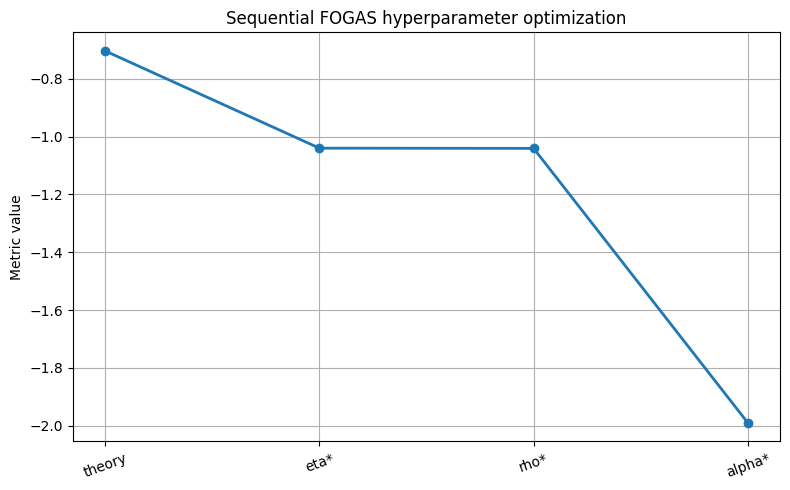

In [6]:
summary = optimizer.optimize_fogas_hyperparameters(
    search_method="random",
    coarse_points=20,
    print_main=True, 
    num_runs=2,
    order=("eta", "rho", "alpha")
)

alpha_star = summary["alpha"]
rho_star = summary["rho"]
eta_star = summary["eta"]

In [8]:
solver.run(alpha=alpha_star, eta=eta_star, rho=rho_star, tqdm_print=True)
evaluator.compare_value_functions()

FOGAS:   0%|          | 0/600 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 600/600 [00:00<00:00, 6593.49it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^π(x) =  199.000000 | Δ =  3.410605e-13
State 1: V*(x) =  200.000000 | V^π(x) =  200.000000 | Δ =  3.410605e-13

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^π(x,a) =  197.010000 | Δ =  3.410605e-13
(x=0, a=1): Q*(x,a) =  199.000000 | Q^π(x,a) =  199.000000 | Δ =  3.410605e-13
(x=1, a=0): Q*(x,a) =  198.010000 | Q^π(x,a) =  198.010000 | Δ =  3.410605e-13
(x=1, a=1): Q*(x,a) =  200.000000 | Q^π(x,a) =  200.000000 | Δ =  3.410605e-13

Norm diagnostics:
||V^π - V*||_2 = 4.823324e-13
||Q^π - Q*||_2 = 6.821210e-13




### Empirical

In [25]:
solver_e = FOGASSolverBetaVectorized(mdp=mdp, print_params=True, csv_path=str(DATASETS_DIR / "dumb_problem.csv"), seed=SEED, device=DEVICE)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"))



Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/dumb_problem.csv (n=100)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           100
Feature norm bound R:     3.4641
Num states N:             2
Num actions A:            2
Feature dim d:            3
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      555.3077115834219
T (iterations):                556

FOGAS Hyperparameters
---------------------
alpha:                        0.000083
rho:                            1680.895969
eta:                            0.000008
D_theta:                    17.320508
beta (ridge):             0.007194
D_pi (derived):           0.801446




Trying same optimal hyperparameters found for the oracle.

In [27]:
solver_e.run(alpha=1e-2, eta=4e-3, rho=0.5, tqdm_print=True, T=1000)
evaluator_e.compare_value_functions()
evaluator_e.compare_final_rewards()
evaluator_e.print_policy()

FOGAS:  23%|██▎       | 231/1000 [00:00<00:00, 2302.08it/s]

FOGAS: 100%|██████████| 1000/1000 [00:00<00:00, 1963.53it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^π(x) =  174.943408 | Δ = -2.405659e+01
State 1: V*(x) =  200.000000 | V^π(x) =  175.943408 | Δ = -2.405659e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^π(x,a) =  173.193974 | Δ = -2.381603e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^π(x,a) =  175.183974 | Δ = -2.381603e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^π(x,a) =  174.193974 | Δ = -2.381603e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^π(x,a) =  176.183974 | Δ = -2.381603e+01

Norm diagnostics:
||V^π - V*||_2 = 3.402116e+01
||Q^π - Q*||_2 = 4.763205e+01



========== FINAL REWARD COMPARISON ==========

J*(π*)   = 1.990000
J(π_FOGAS) = 1.749434
Gap (J* − J) = 2.405659e-01


  State 0: π(a=0|s=0) = 0.12  π(a=1|s=0) = 0.88  --> best action: 1
  State 1: π(a=0|s=1) = 0.12  π(a=1|s=1) = 0.88  --> best action: 1

